In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import pandas as pd
import glob
import re
import shutil
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split
import hashlib
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error

I0000 00:00:1786364965.977166 3389545 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# 1. Trova i file
all_files = glob.glob("**/*.csv", recursive=True)
pattern = re.compile(r"CNN.*ResultsForMicro_(\d+)\.csv$", re.IGNORECASE)

df_list = []
for file in all_files:
    match = pattern.search(file)
    if match:
        # Estrai il numero dal nome del file (il gruppo catturato dalla regex)
        seed_value = match.group(1)
        
        try:
            temp_df = pd.read_csv(file)
            # Aggiungi il campo 'Seed'
            temp_df['Seed'] = int(seed_value)
            df_list.append(temp_df)
        except Exception as e:
            print(f"Errore nella lettura di {file}: {e}")

if df_list:
    full_results = pd.concat(df_list, ignore_index=True)
    
    # 2. Sposta il campo 'Seed' subito dopo la prima colonna
    cols = list(full_results.columns)
    # Rimuovi 'Seed' dalla lista e reinseriscilo in posizione 1
    cols.remove('Seed')
    cols.insert(1, 'Seed')
    full_results = full_results[cols]
    
    # 3. Pulizia MAE_test
    if 'MAE_test' in full_results.columns:
        full_results['MAE_test'] = pd.to_numeric(
            full_results['MAE_test'].astype(str).str.replace('%', '', regex=False).str.strip(), 
            errors='coerce'
        )
    
    # 4. Ordina e salva
    full_results_sorted = full_results.sort_values(by='MAE_test', ascending=True)
    output_filename = "[DL]best_models_summary.csv"
    full_results_sorted.to_csv(output_filename, index=False)
    
    print(f"File salvato: {output_filename}")
    print(full_results_sorted.head())
else:
    print("Nessun file trovato con il pattern specificato.")

File salvato: [DL]best_models_summary.csv
             Model   Seed  Batch_Size  Learning_Rate  Dropout Kernel_Size  \
159   CNN1D_RNN_10  91876          32         0.0003      0.1           5   
1788  CNN1D_RNN_39   1291          32         0.0005      0.1           3   
538   CNN1D_RNN_39     12          32         0.0005      0.1           3   
1488  CNN1D_RNN_39      7          32         0.0005      0.1           3   
1969  CNN1D_RNN_20      8          32         0.0003      0.1           3   

      Train_Last_Epoch  Train_Last_Epoch_Loss  MAE_train  MAPE_train  ...  \
159                 35               0.112289   0.014456    4.389084  ...   
1788                42               0.104992   0.015052    4.417129  ...   
538                 40               0.108249   0.015031    4.426271  ...   
1488                35               0.111740   0.014944    4.554910  ...   
1969                45               0.105902   0.014012    4.263943  ...   

      MSE_test  RMSE_test   R2_t

In [3]:
# 1. Prendi la prima riga del DataFrame ordinato (il migliore)
best_row = full_results_sorted.iloc[0]
best_modello_full = str(best_row['Model'])  # Es. "CNN1D_123"
best_seed = best_row['Seed']                 # Il seed letto in precedenza

# 2. Elimina l'ultima particella "_{numero}" dal nome del modello
base_model_name = re.sub(r'_\d+$', '', best_modello_full)

# 3. Costruisci il nome della cartella di origine: nome base + _{seed}
target_folder = f"{base_model_name}ToEvaluate_{best_seed}"

print(f"Modello migliore: {best_modello_full} (con seed {best_seed})")
print(f"Cartella di origine: {target_folder}")

# 4. Definisci e crea la cartella di destinazione "BestModel" se non esiste
destination_folder = "BestModel"
if os.path.exists(destination_folder):
    shutil.rmtree(destination_folder)
os.makedirs(destination_folder)

# 5. Cerca i file nella cartella di origine e copiali in BestModel
if os.path.exists(target_folder) and os.path.isdir(target_folder):
    pattern_file = re.compile(rf"^{re.escape(best_modello_full)}(?:[_.]|$)")
    target_files = [
        os.path.join(target_folder, f)
        for f in os.listdir(target_folder)
        if pattern_file.match(f)
    ]
    
    if target_files:
        print(f"Trovati {len(target_files)} file. Copia in '{destination_folder}/' in corso...")
        for file_path in target_files:
            # Copia il file mantenendo il nome originale dentro la cartella BestModel
            shutil.copy(file_path, destination_folder)
            print(f" - Copiato: {os.path.basename(file_path)}")
        print("Copia completata con successo!")
    else:
        print(f"Nessun file corrispondente a '{best_modello_full}' trovato dentro '{target_folder}'.")
else:
    print(f"Attenzione: La cartella '{target_folder}' non esiste nel percorso corrente.")

Modello migliore: CNN1D_RNN_10 (con seed 91876)
Cartella di origine: CNN1D_RNNToEvaluate_91876
Trovati 5 file. Copia in 'BestModel/' in corso...
 - Copiato: CNN1D_RNN_10.keras
 - Copiato: CNN1D_RNN_10_float32.cpp
 - Copiato: CNN1D_RNN_10_int8.tflite
 - Copiato: CNN1D_RNN_10_int8.cpp
 - Copiato: CNN1D_RNN_10_float32.tflite
Copia completata con successo!


In [4]:
# Definizione della funzione calculate_stats
def calculate_stats(file_paths, labels, batch_size=64):
    """Creiamo un dataset tf.data per leggere i file in parallelo"""
    def process_path(file_path):
        raw = tf.io.read_file(file_path)
        return tf.io.decode_raw(raw, out_type=tf.float32)

    dataset = tf.data.Dataset.from_tensor_slices(file_paths)
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

    sum_x = 0.0
    sum_sq_x = 0.0
    count_x = 0

    total_batches = (len(file_paths) + batch_size - 1) // batch_size

    print("Calcolo statistiche in corso...")
    for batch in tqdm(dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE), total=total_batches):
        batch_val = batch.numpy()
        sum_x += np.sum(batch_val)
        sum_sq_x += np.sum(np.square(batch_val))
        count_x += batch_val.size

    mean_x = sum_x / count_x
    std_x = np.sqrt(max(sum_sq_x / count_x - mean_x**2, 1e-9))

    mean_y = np.mean(labels)
    std_y = np.std(labels)

    return mean_x, std_x, mean_y, std_y

In [5]:
# 1. Carica il modello .keras migliore dalla cartella BestModel
keras_files = glob.glob(os.path.join("BestModel", "*.keras"))
if not keras_files:
    raise FileNotFoundError("Nessun file .keras trovato nella cartella 'BestModel'.")

best_keras_path = keras_files[0]
print(f"Caricamento del modello: {best_keras_path}")
model = tf.keras.models.load_model(best_keras_path)

# 2. Configurazione file e parametri corretti
DATASET_CSV_FILE = "audio_dataset.csv"
SPECTROGRAMS_DIR = "Spectrograms"
altezza, larghezza = 128, 32  # Dimensioni native corrette

if not os.path.exists(DATASET_CSV_FILE):
    raise FileNotFoundError(f"Impossibile trovare il file '{DATASET_CSV_FILE}' nella directory corrente.")

# 3. FIXED INDEX SPLIT (MATCHING ML MODELS)
temp_df = pd.read_csv(DATASET_CSV_FILE)

if 'filename' not in temp_df.columns or 'portata' not in temp_df.columns:
    raise ValueError("Le colonne 'filename' e/o 'portata' non sono presenti nel dataset.")

# Generiamo due liste di indici basandoci sulla struttura del DataFrame
indices = list(range(len(temp_df)))

# Usiamo lo STESSO IDENTICO train_test_split del Machine Learning sul vettore degli indici
train_indices, test_indices = train_test_split(indices, test_size=0.2, random_state=int(best_seed))

print("SHA256 Train1: "+hashlib.sha256(str(train_indices).encode('utf-8')).hexdigest())
print("SHA256 Test1: "+hashlib.sha256(str(test_indices).encode('utf-8')).hexdigest())

train_indices, val_indices = train_test_split(
    train_indices,
    test_size=0.15,          # 15% dei dati di train va alla validazione
    random_state=int(best_seed),
    shuffle=True             # Mescoliamo gli indici prima di dividerli
)

# Estrazione dei dati di training per il calcolo delle statistiche
train_filenames = temp_df.iloc[train_indices]['filename'].values
train_labels = temp_df.iloc[train_indices]['portata'].values

file_paths = [os.path.join(SPECTROGRAMS_DIR, f.replace('.wav', '_melspec.bin')) for f in train_filenames]

# Calcolo di medie e deviazioni standard basate sul train set (inclusi i target y)
mean_x, std_x, mean_y, std_y = calculate_stats(file_paths, train_labels)

print(f"Stats Input -> Mean: {mean_x}, Std: {std_x}")
print(f"Stats Labels -> Mean: {mean_y}, Std: {std_y}")

# 4. Elaborazione del test set usando gli indici fissi del test_indices
test_df = temp_df.iloc[test_indices].copy()

X_test_list = []
y_test_list = []
valid_indices = []

for idx, row in test_df.iterrows():
    audio_filename = str(row['filename'])
    spec_filename = audio_filename.replace(".wav", "_melspec.bin")
    spec_path = os.path.join(SPECTROGRAMS_DIR, spec_filename)
    
    if os.path.exists(spec_path):
        try:
            # 1. Legge il file in formato binario raw e decodifica in float32
            spec_data = np.fromfile(spec_path, dtype=np.float32)
            
            # 2. Ricostruiamo la matrice (reshape) usando lo shape nativo [Altezza, Larghezza] -> [128, 32]
            matrix = spec_data.reshape(altezza, larghezza)
            
            # 3. Standardizzazione Z-Score dell'input con le statistiche del train
            matrix = (matrix - mean_x) / (std_x + 1e-6)
            
            # 4. Trasponiamo la matrice: da [128, 32] a [32, 128] (Esattamente come in training)
            matrix_transposed = matrix.T 
            
            X_test_list.append(matrix_transposed)
            y_test_list.append(row['portata'])
            valid_indices.append(idx)
        except Exception as e:
            print(f"Errore nella lettura di {spec_path}: {e}")

# Filtriamo mantenendo solo gli indici con spettrogramma valido
test_df_filtered = test_df.loc[valid_indices].copy()

# 5. Effettua le predizioni e de-standardizza l'output del modello
if X_test_list:
    X_test_array = np.array(X_test_list)
    predictions = model.predict(X_test_array)
    y_pred_normalized = predictions.flatten() if predictions.ndim > 1 else predictions
    
    # De-standardizzazione delle predizioni per riportarle nella scala originale della portata
    y_pred = (y_pred_normalized * std_y) + mean_y
    
    y_test = np.array(y_test_list)
else:
    raise ValueError("Nessuno spettrogramma valido trovato per il test set.")

# Creazione delle Series con l'indice filename
y_test_series = pd.Series(y_test, index=test_df_filtered['filename'])
y_pred_series = pd.Series(y_pred, index=test_df_filtered['filename'])

# --- 5.1 CALCOLO DEL MAE ---
overall_mae = mean_absolute_error(y_test_series, y_pred_series)
print(f"\n========================================")
print(f" Mean Absolute Error (MAE) Globale: {overall_mae:.8f}")
print(f"========================================\n")

Caricamento del modello: BestModel/CNN1D_RNN_10.keras


I0000 00:00:1786364967.745279 3389545 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21870 MB memory:  -> device: 0, name: NVIDIA RTX 5000 Ada Generation, pci bus id: 0000:55:00.0, compute capability: 8.9


SHA256 Train1: da546bfa3caa1a1fab41fe80eed89539f992c14c4d61691e6e71d0c0492f26aa
SHA256 Test1: df90697eff376256e6ded58980ca6dab075472342b02d62f86747e341d96ce6d
Calcolo statistiche in corso...


100%|██████████| 102/102 [00:00<00:00, 2038.65it/s]

Stats Input -> Mean: -60.698692321777344, Std: 12.708149909973145
Stats Labels -> Mean: 0.38474632866537184, Std: 0.16673187280278606



I0000 00:00:1786364969.967935 3389656 service.cc:153] XLA service 0x7316f00fd760 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786364969.967971 3389656 service.cc:161]   StreamExecutor [0]: NVIDIA RTX 5000 Ada Generation, Compute Capability 8.9 (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786364969.983055 3389656 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786364970.510004 3389656 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1786364970.521174 3389656 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1187__.1
I0000 00:00:1786364970.773713 3389656 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set inste

 1/60 ━━━━━━━━━━━━━━━━━━━━ 2:39 3s/step

I0000 00:00:1786364972.447495 3389656 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1786364973.246693 3389660 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2156__.1
I0000 00:00:1786364973.321150 3389660 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step

 Mean Absolute Error (MAE) Globale: 0.01736417



In [6]:
# 6. Definizione della cartella di output e della funzione di plotting
OUTPUT_DIR = Path("PredizioniVSGroundTruth")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
def plot_predictions(y_test, y_pred):
    """Confronta y_test e y_pred creando un grafico giornaliero,
    impostando la medesima scala Y e la medesima scala X (intervallo di 24 ore)
    per tutti i grafici, includendo il giorno nel titolo e salvando in un percorso.
    """
    df_plot = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred}, index=y_test.index)

    timestamps = (
        df_plot.index.str.replace('audio_', '', regex=False)
        .str.replace('.wav', '', regex=False)
        .str.strip()
    )
    df_plot['datetime'] = pd.to_datetime(timestamps, format='%Y-%m-%dT%H-%M-%S')
    df_plot['date'] = df_plot['datetime'].dt.date

    df_plot = df_plot.sort_values(by='datetime')

    y_min = min(df_plot['y_test'].min(), df_plot['y_pred'].min())
    y_max = max(df_plot['y_test'].max(), df_plot['y_pred'].max())
    padding = (y_max - y_min) * 0.05 if y_max != y_min else 1.0
    ylimits = (y_min - padding, y_max + padding)

    for giorno, gruppo in df_plot.groupby('date'):
        fig, ax = plt.subplots(figsize=(12, 5))

        ax.plot(
            gruppo['datetime'],
            gruppo['y_test'],
            label='Ground Truth',
            color='blue',
            marker='o',
            linestyle='-',
            alpha=0.8,
        )
        ax.plot(
            gruppo['datetime'],
            gruppo['y_pred'],
            label='Predizioni',
            color='orange',
            marker='x',
            linestyle='--',
            alpha=0.8,
        )

        ax.set_title(
            f'Predizione vs Ground Truth - {giorno}',
            fontsize=14,
            fontweight='bold',
        )
        ax.set_xlabel('Timestamp', fontsize=12)
        ax.set_ylabel('Portata', fontsize=12)

        ax.set_ylim(ylimits)

        start_of_day = pd.to_datetime(str(giorno) + ' 00:00:00')
        end_of_day = pd.to_datetime(str(giorno) + ' 23:59:59')
        ax.set_xlim([start_of_day, end_of_day])

        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        fig.autofmt_xdate()

        ax.legend(fontsize=12)
        ax.grid(True, linestyle=':', alpha=0.6)

        filename = OUTPUT_DIR / f'Confronto_{giorno}.png'
        plt.tight_layout()
        plt.savefig(filename, dpi=300)
        plt.show()
        plt.close(fig)

    print(
        f"Tutti i grafici sono stati salvati correttamente nella cartella:"
        f" '{OUTPUT_DIR.resolve()}'"
    )

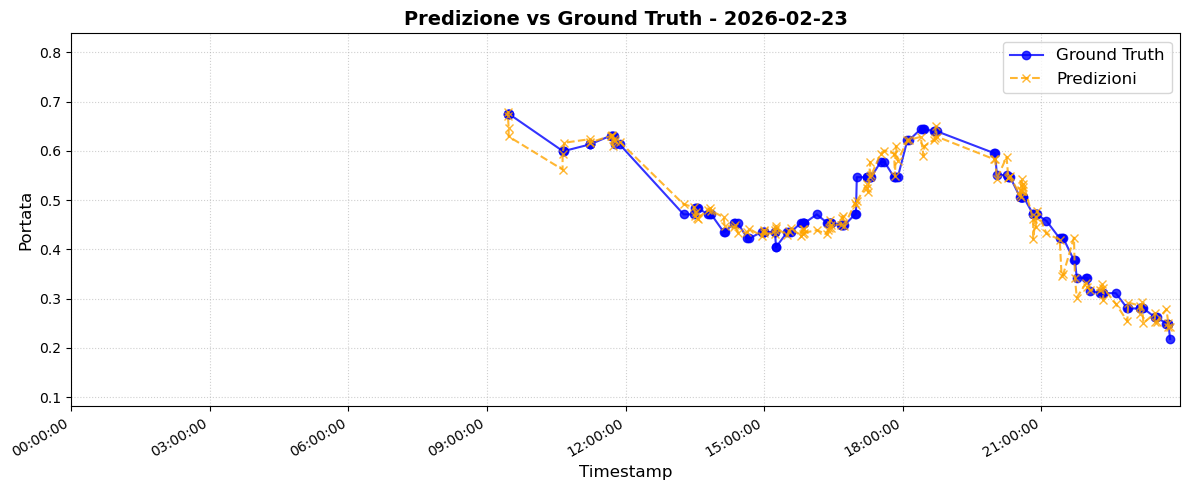

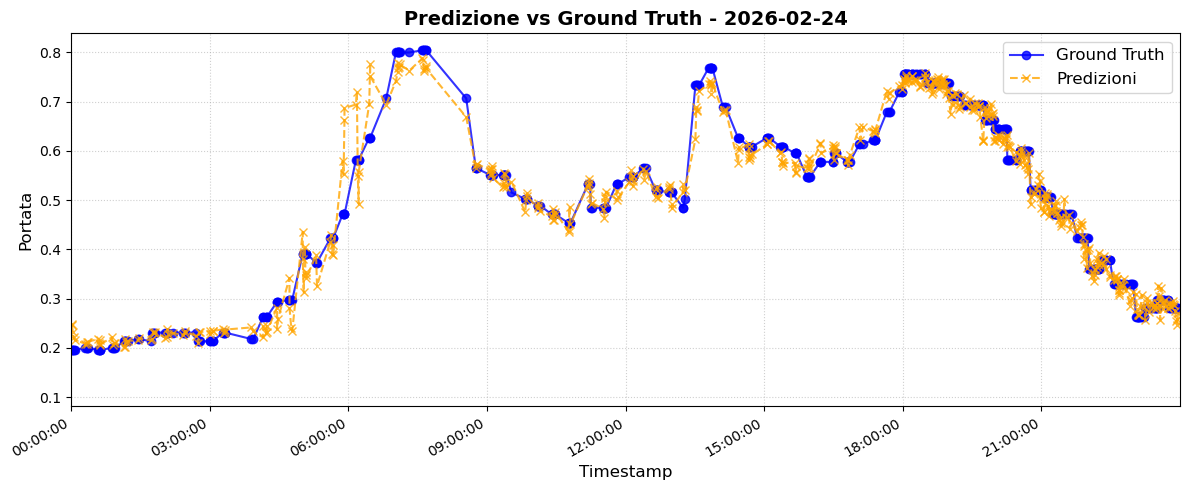

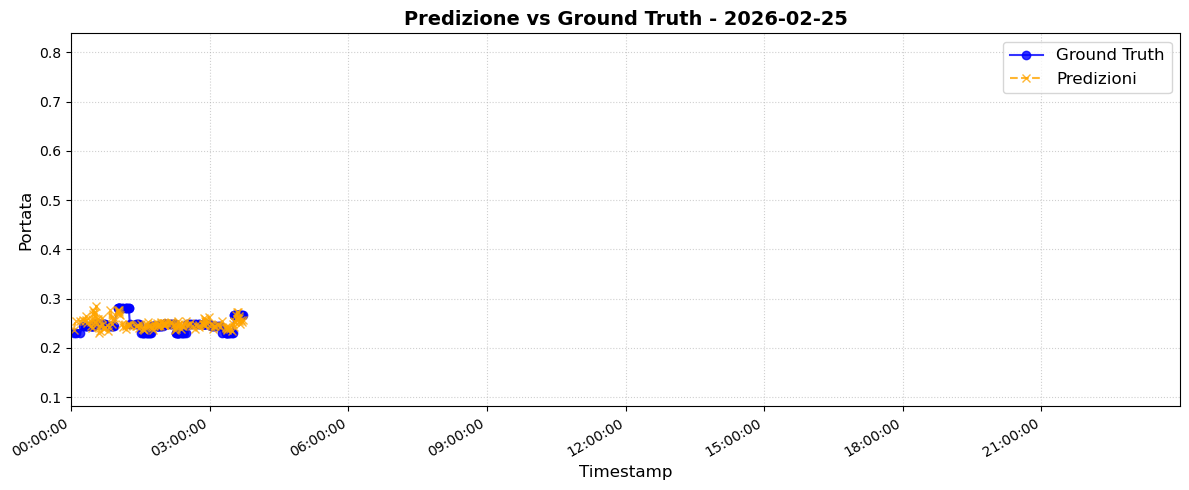

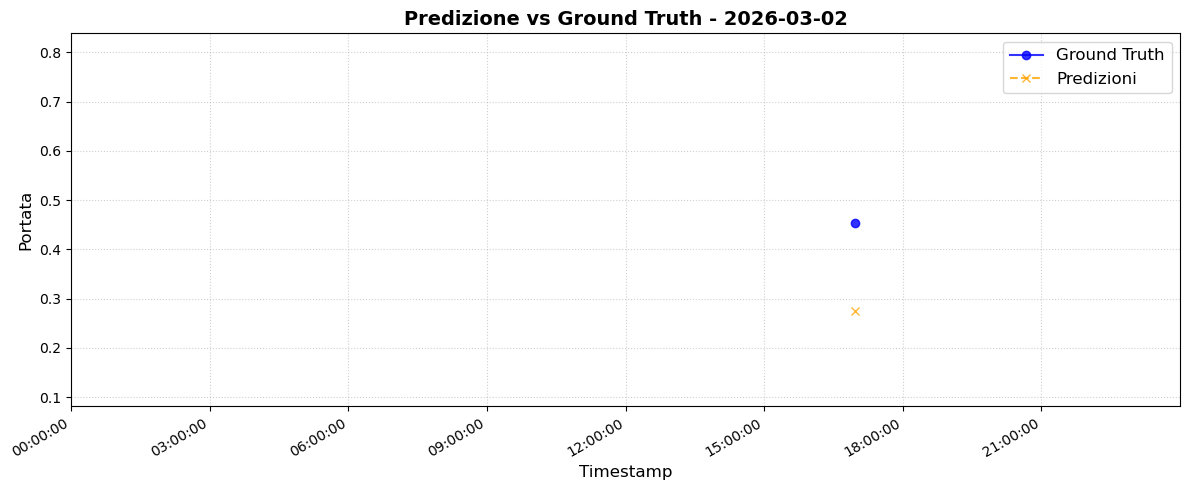

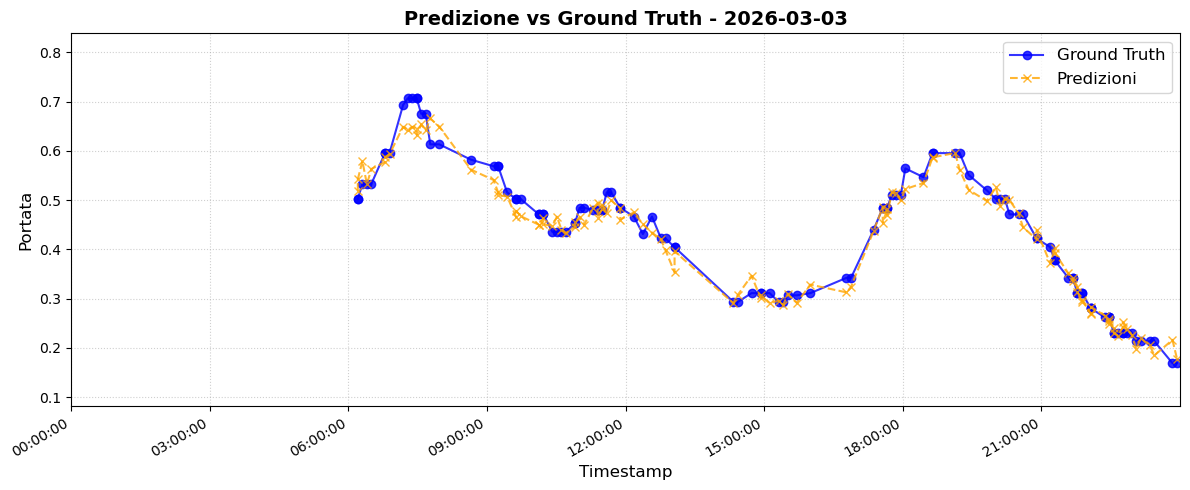

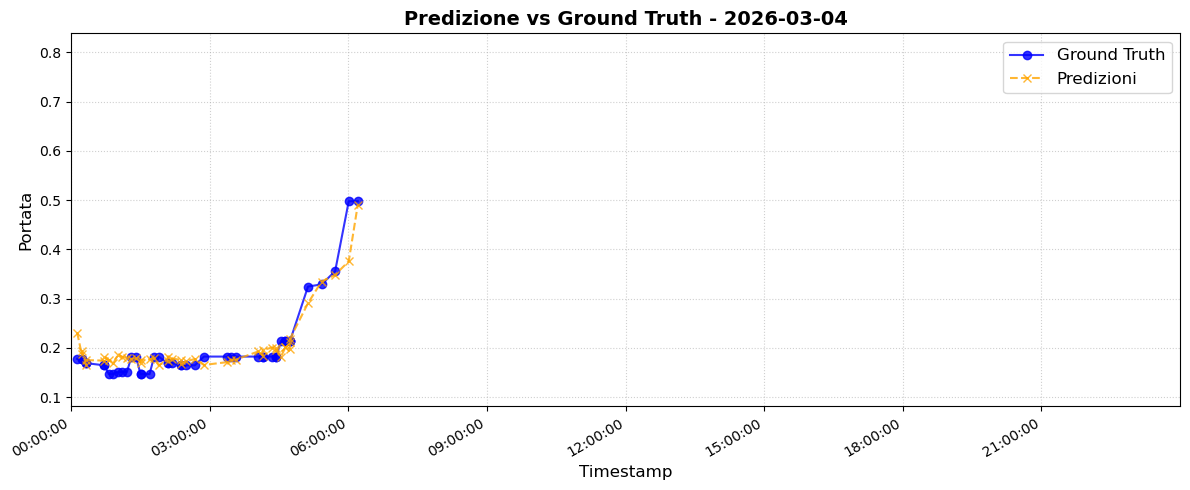

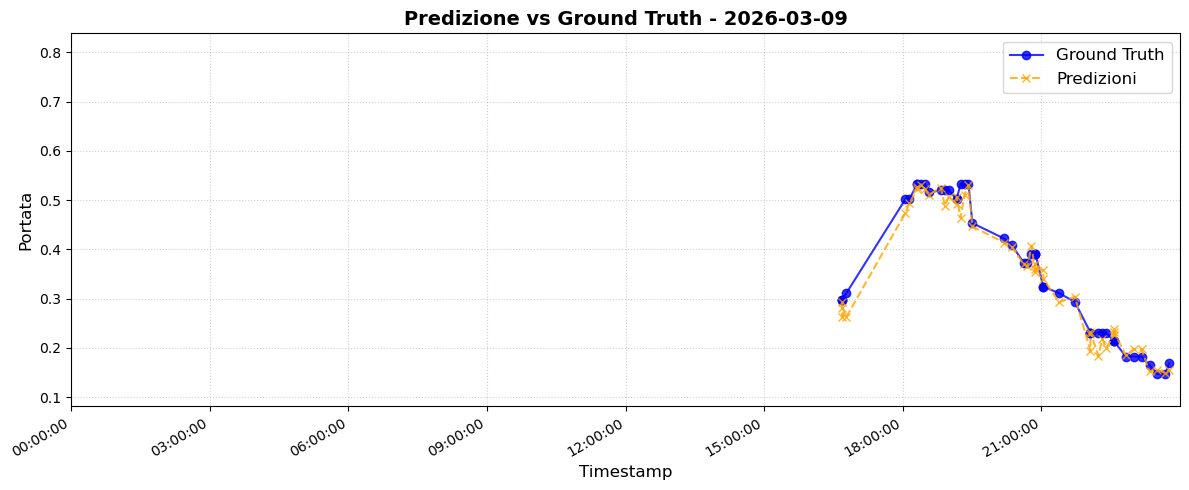

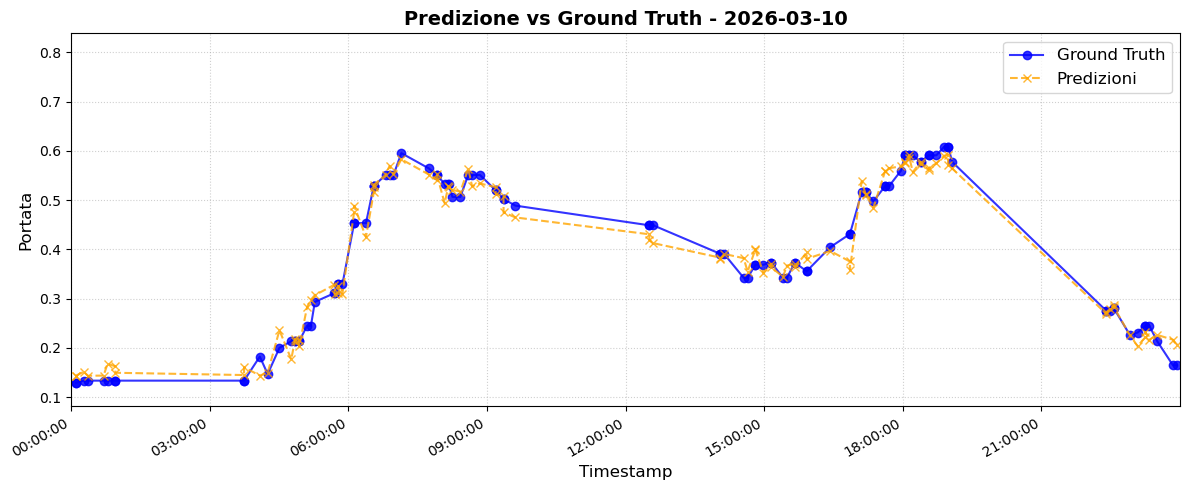

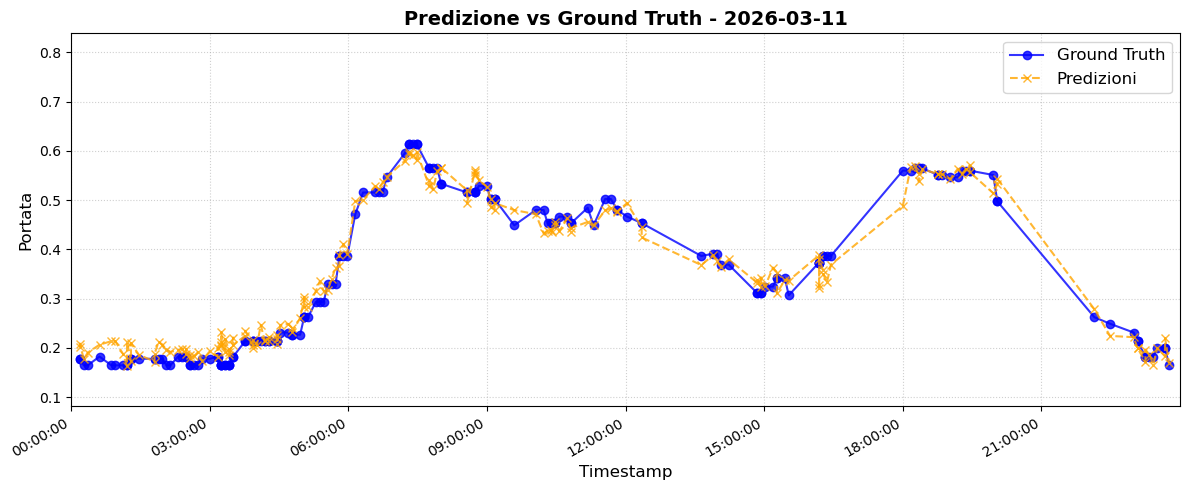

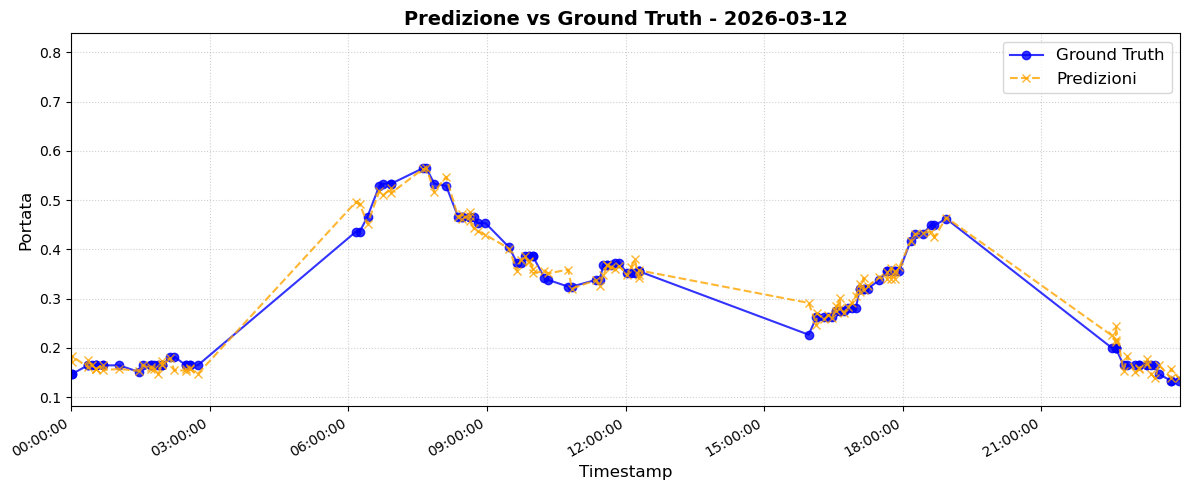

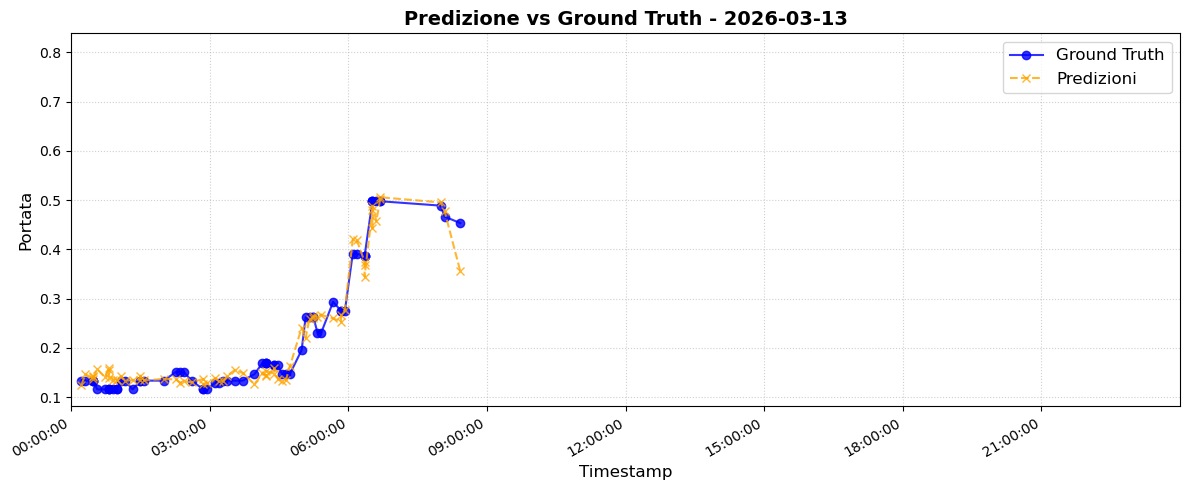

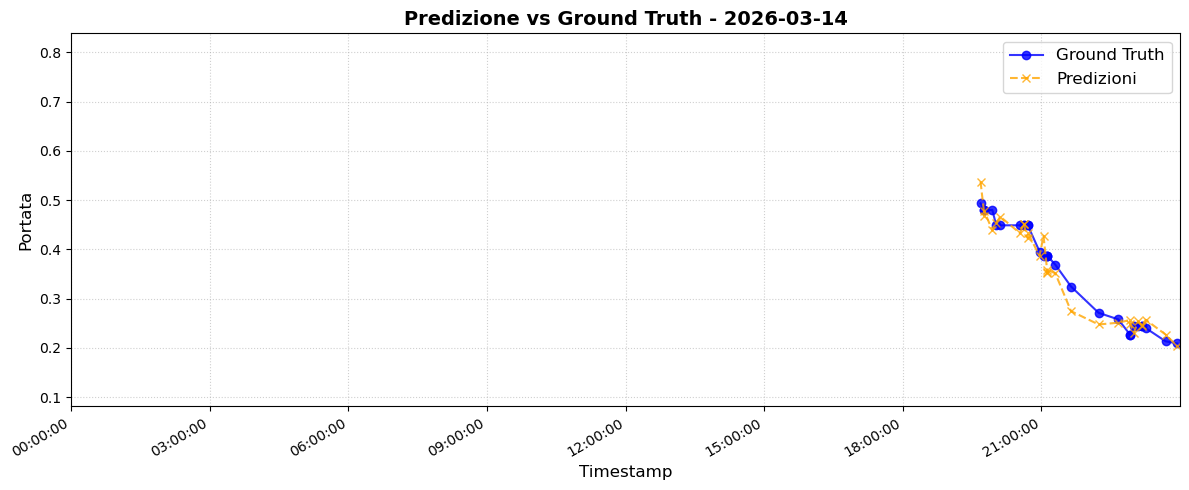

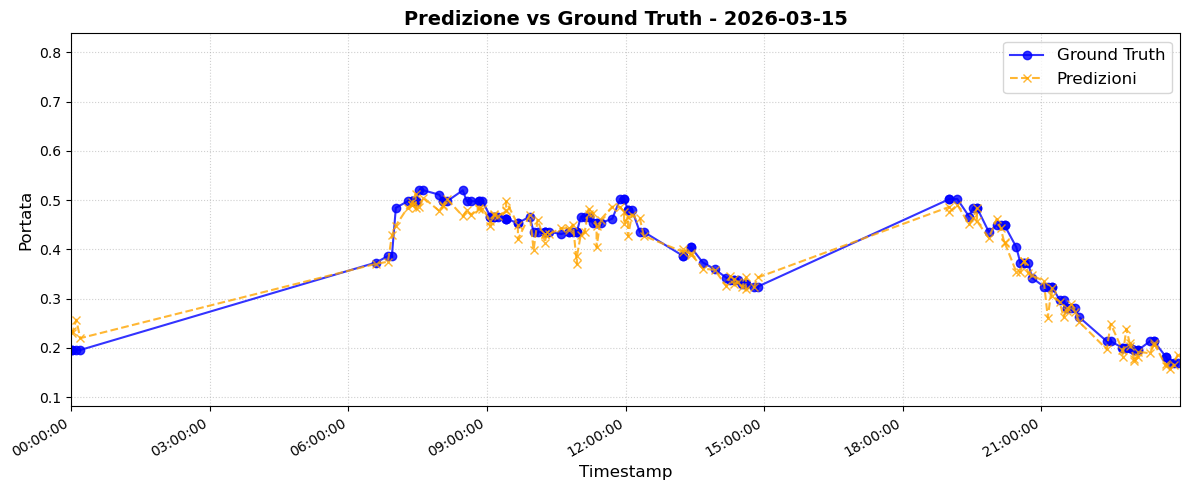

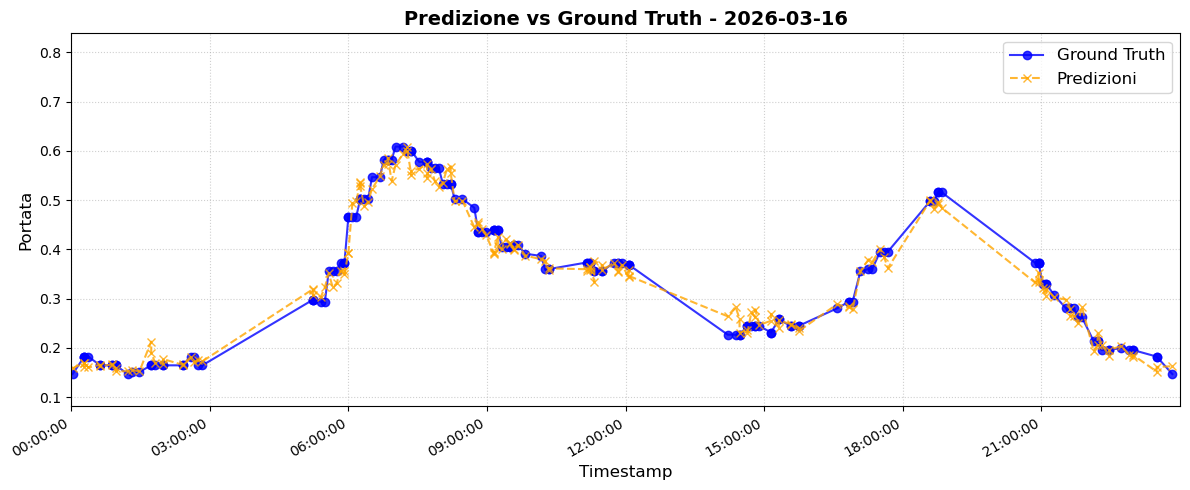

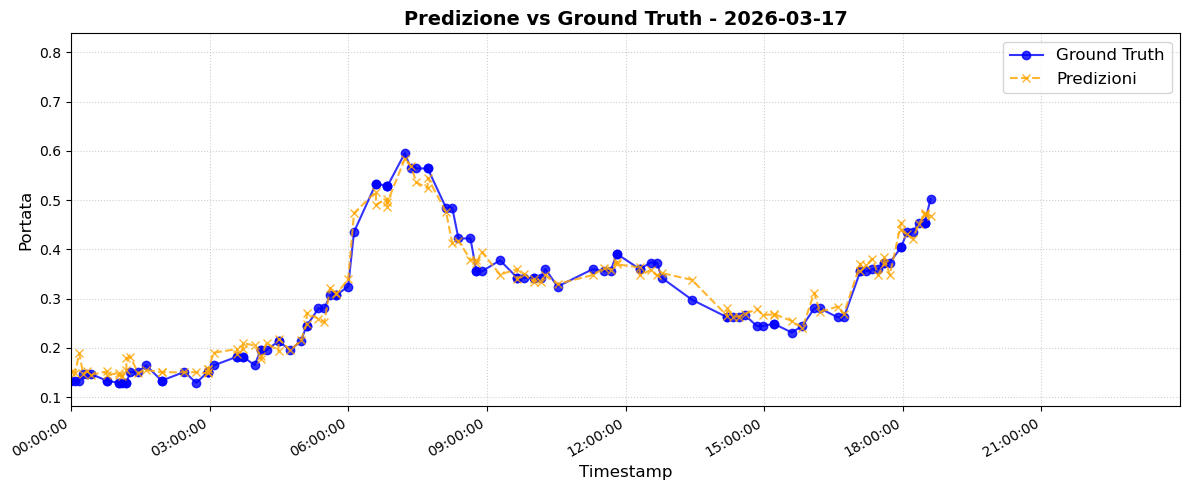

Tutti i grafici sono stati salvati correttamente nella cartella: '/home/christian_cioffi/PredizioniVSGroundTruth'


In [8]:
# 7. Esegui la funzione di plot
plot_predictions(y_test_series, y_pred_series)